In [22]:
import pandas as pd

# 1. Carga de datasets principales
try:
    df_orders = pd.read_csv('olist_orders_dataset.csv')
    df_payments = pd.read_csv('olist_order_payments_dataset.csv')
    print("✅ ¡Bases de datos cargadas con éxito!")
except FileNotFoundError:
    print("❌ Error: No encuentro los archivos CSV. Asegurate de que estén en la misma carpeta que este archivo .ipynb")

# 2. Resumen rápido de la magnitud de la empresa
print(f"\n- Cantidad de órdenes: {df_orders.shape[0]:,}")
print(f"- Cantidad de registros de pago: {df_payments.shape[0]:,}")

# 3. Vista previa de los registros de pago
df_payments.head()

✅ ¡Bases de datos cargadas con éxito!

- Cantidad de órdenes: 99,441
- Cantidad de registros de pago: 103,886


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [23]:
# 1. Filtramos las órdenes entregadas
delivered_orders = df_orders[df_orders['order_status'] == 'delivered']

# 2. Cruzamos (Merge) las órdenes con los pagos
# Queremos ver si a cada orden entregada le corresponde al menos un pago
audit_merge = pd.merge(delivered_orders, df_payments, on='order_id', how='left')

# 3. Identificamos órdenes SIN pago (donde el valor del pago es nulo)
missing_payments = audit_merge[audit_merge['payment_value'].isna()]

# 4. Calculamos el impacto
total_missing = len(missing_payments)
print(f"🔎 RESULTADO DE LA AUDITORÍA:")
print(f"-----------------------------------")
print(f"Se detectaron {total_missing} órdenes entregadas que NO tienen registro de pago.")

if total_missing > 0:
    print(f"⚠️ Se detectaron órdenes entregadas sin registro de pago. Se recomienda investigación.")
    # Mostramos las primeras 5 para investigar
    display(missing_payments[['order_id', 'customer_id', 'order_status']].head())
else:
    print(f"✅ Todo en orden. Todas las entregas están respaldadas por un pago.")

🔎 RESULTADO DE LA AUDITORÍA:
-----------------------------------
Se detectaron 1 órdenes entregadas que NO tienen registro de pago.
⚠️ Se detectaron órdenes entregadas sin registro de pago. Se recomienda investigación.


,order_id,customer_id,order_status
31175,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered


In [24]:
# 1. Detalle de la orden sin registro de pago
order_id_anomalia = missing_payments['order_id'].iloc[0]

# 2. Información completa de la orden en el dataset original
detalle_orden = df_orders[df_orders['order_id'] == order_id_anomalia]

print(f"--- DETALLE DE ORDEN AUDITADA ---")
print(f"ID de Orden: {order_id_anomalia}")
display(detalle_orden)

# 3. Verificación cruzada en tabla de pagos
verificacion_pago = df_payments[df_payments['order_id'] == order_id_anomalia]

if verificacion_pago.empty:
    print(f"\n❌ CONFIRMADO: No existe registro de pago para la orden {order_id_anomalia}.")
else:
    print(f"\n✅ El pago existe pero no fue detectado en el cruce inicial. Revisar lógica del merge.")

--- DETALLE DE ORDEN AUDITADA ---
ID de Orden: bfbd0f9bdef84302105ad712db648a6c


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
30710,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04 00:00:00



❌ CONFIRMADO: No existe registro de pago para la orden bfbd0f9bdef84302105ad712db648a6c.


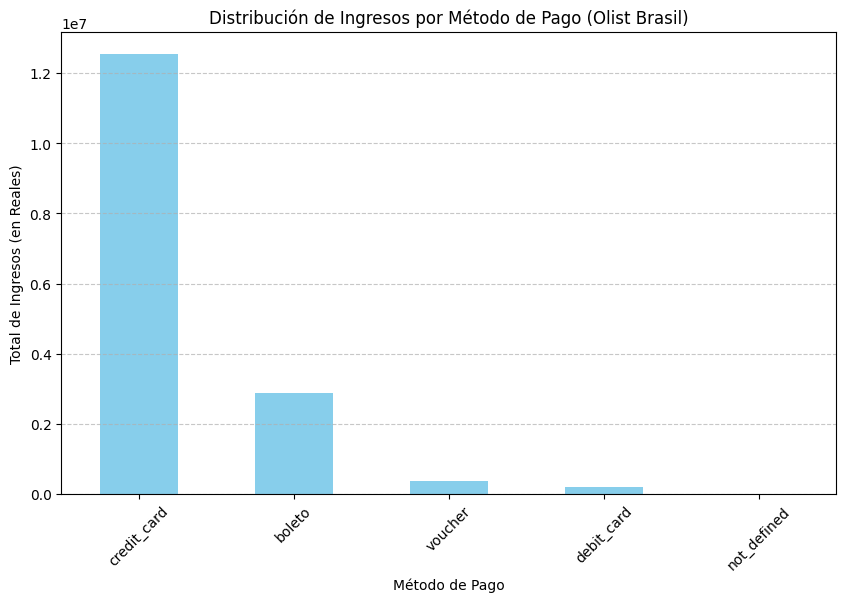

In [25]:
import matplotlib.pyplot as plt

# 1. Ingresos totales por método de pago
pagos_por_metodo = df_payments.groupby('payment_type')['payment_value'].sum().sort_values(ascending=False)

# 2. Gráfico de barras
plt.figure(figsize=(10, 6))
pagos_por_metodo.plot(kind='bar', color='skyblue')

# 3. Formato del gráfico
plt.title('Distribución de Ingresos por Método de Pago (Olist Brasil)')
plt.xlabel('Método de Pago')
plt.ylabel('Total de Ingresos (en Reales)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.savefig('grafico_metodos_pago.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# 1. Conversión de columnas de fecha a formato datetime
df_orders['order_purchase_timestamp'] = pd.to_datetime(df_orders['order_purchase_timestamp'])
df_orders['order_delivered_customer_date'] = pd.to_datetime(df_orders['order_delivered_customer_date'])

# 2. Cálculo de Lead Time: días entre compra y entrega
df_orders['lead_time_days'] = (df_orders['order_delivered_customer_date'] - df_orders['order_purchase_timestamp']).dt.days

# 3. Filtro sobre órdenes entregadas para evitar valores nulos
entregas = df_orders[df_orders['order_status'] == 'delivered'].copy()

promedio_entrega = entregas['lead_time_days'].mean()
entrega_maxima = entregas['lead_time_days'].max()

print(f"📊 DESEMPEÑO LOGÍSTICO (KPIs):")
print(f"-----------------------------------")
print(f"Promedio de entrega: {promedio_entrega:.1f} días.")
print(f"La entrega más lenta tardó: {entrega_maxima:.0f} días.")

# 4. Detección de pedidos con demora crítica (>30 días) — riesgo de reclamo y pérdida de cliente
demoras_criticas = entregas[entregas['lead_time_days'] > 30]
print(f"\n⚠️ Se detectaron {len(demoras_criticas)} pedidos con demora mayor a 1 mes.")

📊 DESEMPEÑO LOGÍSTICO (KPIs):
-----------------------------------
Promedio de entrega: 12.1 días.
La entrega más lenta tardó: 209 días.

⚠️ Se detectaron 4117 pedidos con demora mayor a 1 mes.


📍 TOP 10 ESTADOS CON MÁS DEMORAS (> 30 días):
customer_state
RJ    1079
SP     463
BA     355
RS     322
MG     233
PA     196
CE     178
SC     176
PE     158
MA     105
Name: count, dtype: int64


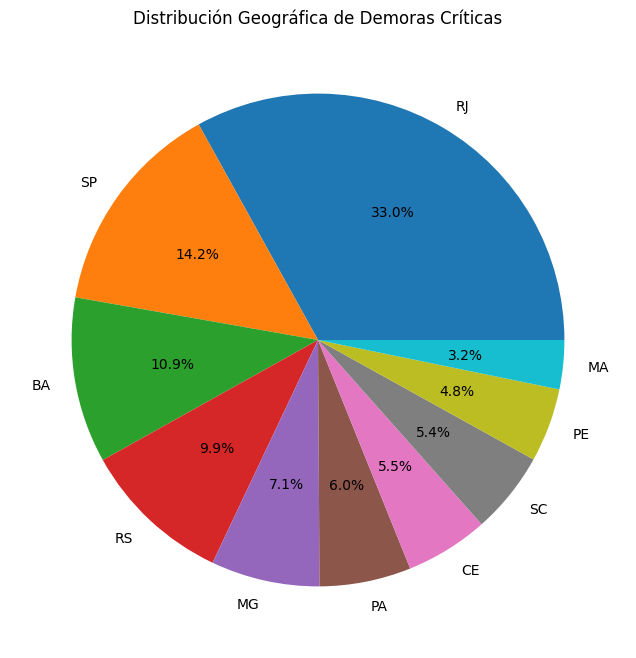

In [27]:
# 1. Carga de tabla de clientes para obtener datos geográficos
df_customers = pd.read_csv('olist_customers_dataset.csv')

# 2. Cruce entre demoras críticas y datos del cliente
analisis_demoras = pd.merge(demoras_criticas, df_customers, on='customer_id', how='left')

# 3. Concentración de demoras por estado
top_demoras_estados = analisis_demoras['customer_state'].value_counts().head(10)

print("📍 TOP 10 ESTADOS CON MÁS DEMORAS (> 30 días):")
print(top_demoras_estados)

# 4. Distribución geográfica de demoras críticas
ax = top_demoras_estados.plot(kind='pie', autopct='%1.1f%%', figsize=(8,8), title='Distribución Geográfica de Demoras Críticas')
plt.savefig('grafico_demoras_geograficas.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
# 1. Consolidación de hallazgos
resumen_datos = {
    "Concepto": [
        "Total de Órdenes Auditadas",
        "Anomalías Detectadas (Entregas sin Registro de Pago)",
        "Promedio de Entrega (Días)",
        "Pedidos con Demora Crítica (>30 días)",
        "Estado con Mayor Concentración de Demoras"
    ],
    "Valor": [
        f"{len(df_orders):,}",
        f"{total_missing}",
        f"{promedio_entrega:.1f} días",
        f"{len(demoras_criticas):,}",
        f"{top_demoras_estados.index[0]} ({top_demoras_estados.iloc[0]} pedidos)"
    ]
}

# 2. DataFrame de reporte final
df_reporte_final = pd.DataFrame(resumen_datos)

print("📈 INFORME FINAL DE AUDITORÍA LOGÍSTICO-CONTABLE")
print("==================================================")
display(df_reporte_final)

# 3. Exportar reporte de auditoría a Excel
df_reporte_final.to_excel('reporte_auditoria_olist.xlsx', index=False)
print("\n✅ Reporte exportado a Excel con éxito.")

📈 INFORME FINAL DE AUDITORÍA LOGÍSTICO-CONTABLE


,Concepto,Valor
0,Total de Órdenes Auditadas,"99,441"
1,Anomalías Detectadas (Entregas sin Registro de...,1
2,Promedio de Entrega (Días),12.1 días
3,Pedidos con Demora Crítica (>30 días),"4,117"
4,Estado con Mayor Concentración de Demoras,RJ (1079 pedidos)



✅ Reporte exportado a Excel con éxito.


## 📋 Recomendaciones

### Integridad financiera

- Implementar una validación automática post-entrega que verifique la existencia de registro de pago antes de cerrar la orden en el sistema. La orden detectada sin pago sugiere una brecha en el proceso de cierre.

### Performance logística

- **RJ concentra el 33% de las demoras críticas** con 1.079 pedidos por encima de los 30 días. Se recomienda revisar los contratos con transportistas locales y evaluar la incorporación de operadores logísticos alternativos en esa región.
- Implementar alertas automáticas para órdenes que superen los 20 días sin entrega, permitiendo intervención preventiva antes de alcanzar el umbral crítico de 30 días.
- La entrega más lenta registrada fue de 209 días — un caso extremo que sugiere una orden abandonada en el sistema sin seguimiento. Se recomienda una política de cierre automático para órdenes inactivas.

### Método de pago

- La tarjeta de crédito domina con ~78% del ingreso. Diversificar los incentivos hacia otros métodos (débito, boleto) puede reducir el riesgo operativo ante eventuales fallas del procesador principal.
